Index(['Dato, time', 'Gjennomsnitt Pris (øre/kWh)'], dtype='str')
             Datetime  MWh  Price_ore_kWh
0 2025-01-01 00:00:00  0.0          8.457
1 2025-01-01 01:00:00  0.0          7.030
2 2025-01-01 02:00:00  0.0          6.688
3 2025-01-01 03:00:00  0.0          6.499
4 2025-01-01 04:00:00  0.0          6.770
Antall timer etter merge: 8760
Index(['Datetime', 'MWh', 'Price_ore_kWh'], dtype='str')
=== NØKKELTALL CASE 1 ===
Total energi: 265162.1 MWh
Total inntekt: 41,662,601 kr
Driftstimer: 6225
Antall oppstarter: 65
Gjennomsnittlig effekt i drift: 42.60 MW
             Datetime  MWh  Price_ore_kWh  P_MW  Power_W  Q_m3s
0 2025-01-01 00:00:00  0.0          8.457   0.0      0.0    0.0
1 2025-01-01 01:00:00  0.0          7.030   0.0      0.0    0.0
2 2025-01-01 02:00:00  0.0          6.688   0.0      0.0    0.0
3 2025-01-01 03:00:00  0.0          6.499   0.0      0.0    0.0
4 2025-01-01 04:00:00  0.0          6.770   0.0      0.0    0.0
                Datetime   MWh  Price_ore_kWh  

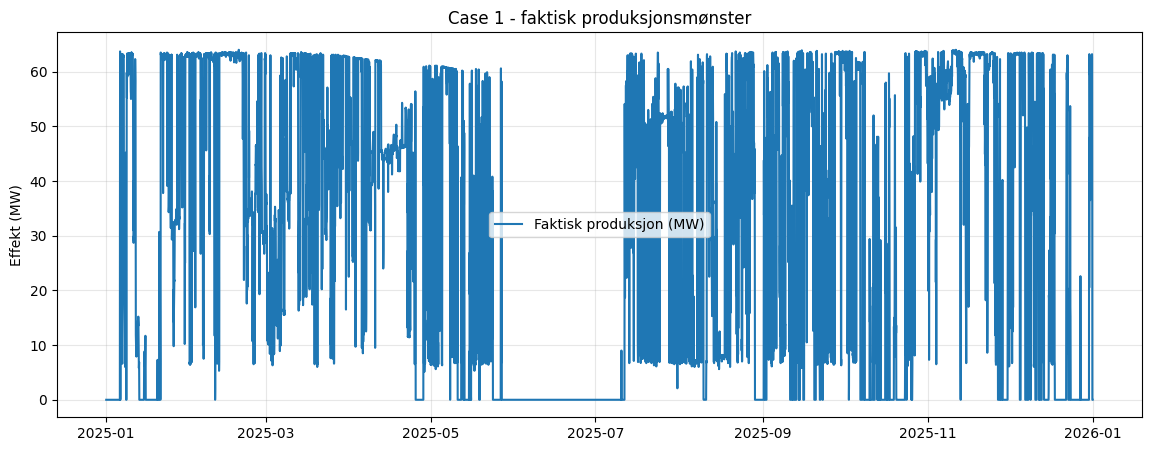

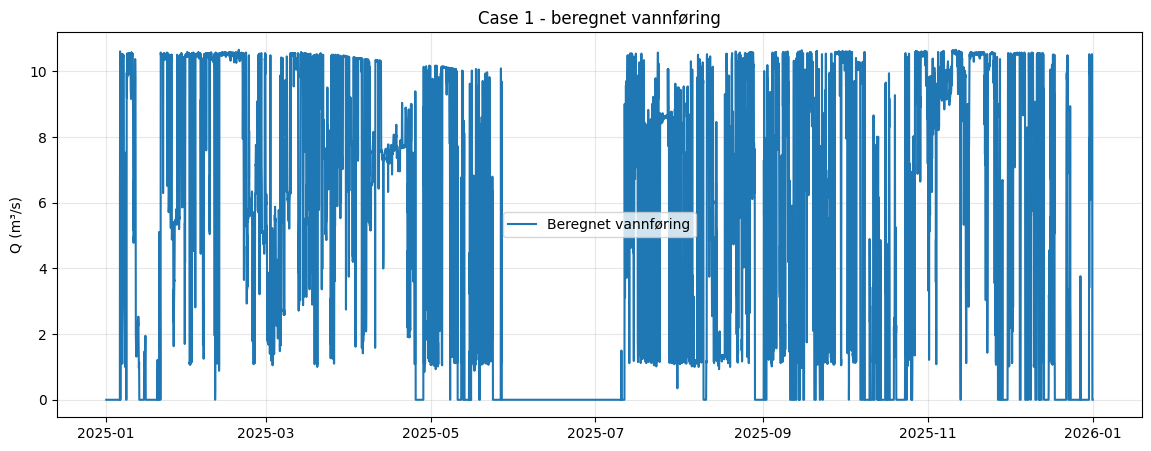

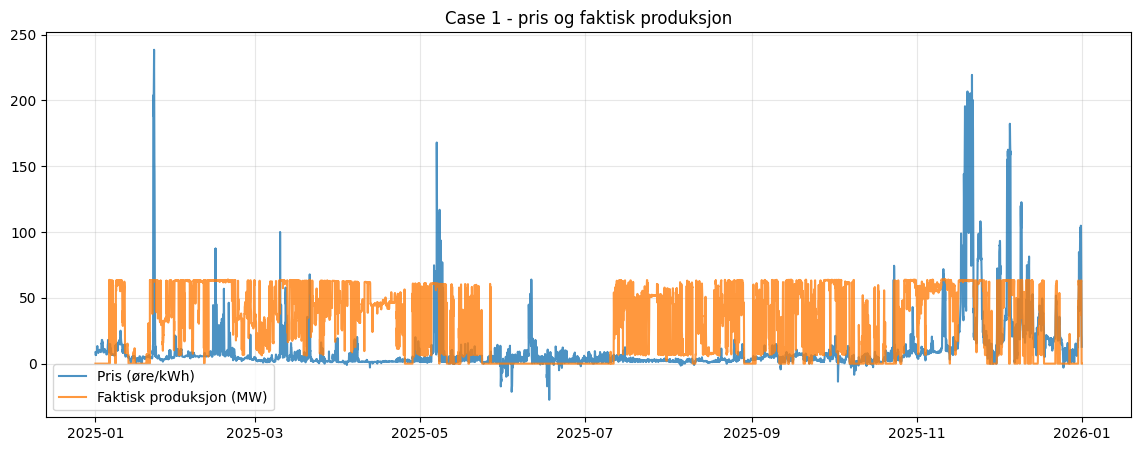

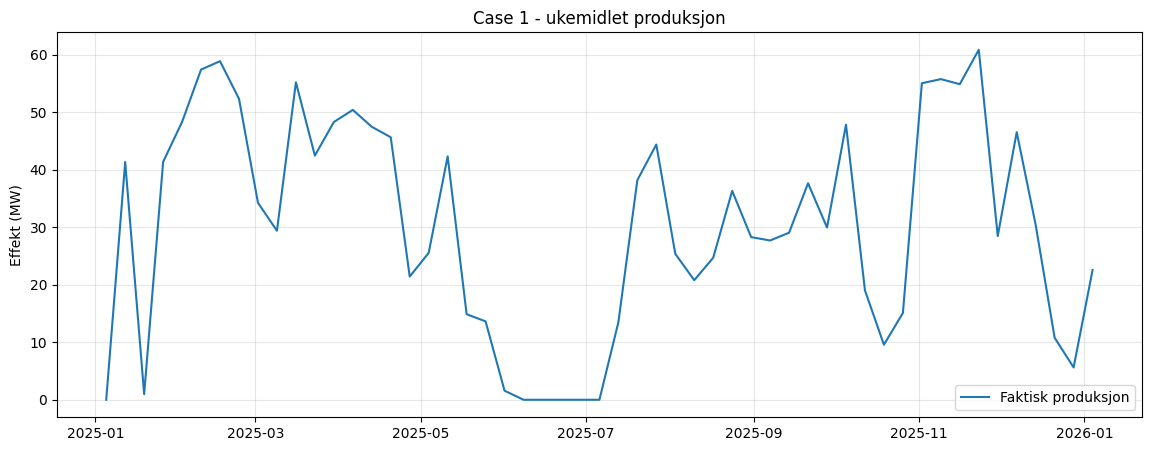

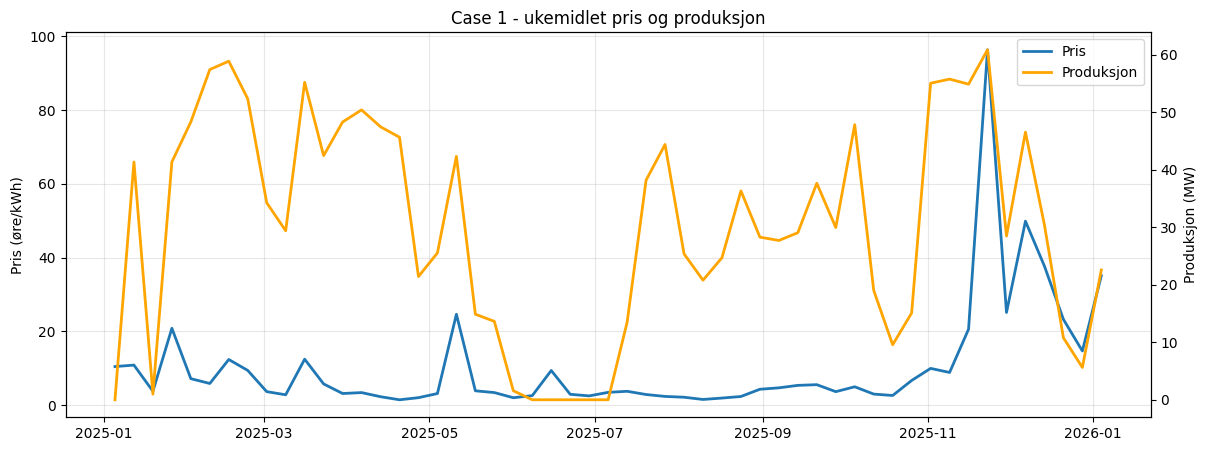

In [5]:
# Case 1 - FAKTISK DRIFTSMØNSTER

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

prod = pd.read_excel("Sildvik_2025_produksjon_ferdig.xlsx", engine="openpyxl")
prod.columns = ["Tid_raw", "MWh"]

datetimes = []
current_date = None

for value in prod["Tid_raw"]:
    value = str(value).strip()

    if "." in value:
        parts = value.split()
        date_part = parts[0]
        hour_part = int(parts[1])
        current_date = pd.to_datetime(date_part, format="%d.%m.%y")
    else:
        hour_part = int(float(value))

    dt = current_date + pd.Timedelta(hours=hour_part - 1)
    datetimes.append(dt)

prod["Datetime"] = datetimes
prod["MWh"] = pd.to_numeric(prod["MWh"], errors="coerce")

df = prod[["Datetime", "MWh"]].dropna().reset_index(drop=True)

# Leser inn prisdata

price = pd.read_excel("Pris_2025 (1).xlsx", engine="openpyxl")

print(price.columns)   # kjør først for å sjekke navn

# Rydd prisdata
price = price.rename(columns={
    "Dato, time": "Datetime",
    "Gjennomsnitt Pris (øre/kWh)": "Price_ore_kWh"
})

price["Datetime"] = pd.to_datetime(price["Datetime"])
price["Price_ore_kWh"] = pd.to_numeric(price["Price_ore_kWh"], errors="coerce")

# Koble produksjon og pris
df = pd.merge(df, price[["Datetime", "Price_ore_kWh"]], on="Datetime", how="inner")

print(df.head())
print("Antall timer etter merge:", len(df))
print(df.columns)

# Beregn vannføring basert på produksjon

rho = 1000
g = 9.81
H = 680
eta = 0.90

df["P_MW"] = df["MWh"]          # MWh per time = MW
df["Power_W"] = df["P_MW"] * 1e6
df["Q_m3s"] = df["Power_W"] / (eta * rho * g * H)

# Nøkkeltall for case 1

total_energy = df["MWh"].sum()
total_income = (df["MWh"] * df["Price_ore_kWh"] * 1000 / 100).sum()
drift_hours = (df["MWh"] > 0).sum()
starts = ((df["MWh"] > 0) & (df["MWh"].shift(1, fill_value=0) == 0)).sum()
avg_power_when_running = df.loc[df["MWh"] > 0, "P_MW"].mean()

print("=== NØKKELTALL CASE 1 ===")
print(f"Total energi: {total_energy:.1f} MWh")
print(f"Total inntekt: {total_income:,.0f} kr")
print(f"Driftstimer: {drift_hours}")
print(f"Antall oppstarter: {starts}")
print(f"Gjennomsnittlig effekt i drift: {avg_power_when_running:.2f} MW")

print(df.head())
print(df.tail())
print("Antall timer:", len(df))

# PLOTS CASE 1

plt.figure(figsize=(14, 5))
plt.plot(df["Datetime"], df["P_MW"], label="Faktisk produksjon (MW)")
plt.ylabel("Effekt (MW)")
plt.title("Case 1 - faktisk produksjonsmønster")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

plt.figure(figsize=(14, 5))
plt.plot(df["Datetime"], df["Q_m3s"], label="Beregnet vannføring")
plt.title("Case 1 - beregnet vannføring")
plt.ylabel("Q (m³/s)")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

plt.figure(figsize=(14, 5))
plt.plot(df["Datetime"], df["Price_ore_kWh"], label="Pris (øre/kWh)", alpha=0.8)
plt.plot(df["Datetime"], df["P_MW"], label="Faktisk produksjon (MW)", alpha=0.8)
plt.title("Case 1 - pris og faktisk produksjon")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

df_plot = df.copy()
df_plot = df_plot.set_index("Datetime")

weekly = df_plot.resample("W").mean(numeric_only=True)

plt.figure(figsize=(14, 5))
plt.plot(weekly.index, weekly["P_MW"], label="Faktisk produksjon")
plt.title("Case 1 - ukemidlet produksjon")
plt.ylabel("Effekt (MW)")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

plt.figure(figsize=(14, 5))

ax1 = plt.gca()
ax1.plot(weekly.index, weekly["Price_ore_kWh"], label="Pris", linewidth=2)
ax1.set_ylabel("Pris (øre/kWh)")
ax1.set_title("Case 1 - ukemidlet pris og produksjon")
ax1.grid(True, alpha=0.3)

ax2 = ax1.twinx()
ax2.plot(weekly.index, weekly["P_MW"], label="Produksjon", linewidth=2, color="orange")
ax2.set_ylabel("Produksjon (MW)")

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2)

plt.show()

In [4]:

print("Turbinvann Case 1:", (df["Q_m3s"] * 3600).sum() / 1e6, "mill. m³/år")


Turbinvann Case 1: 158.9986808178929 mill. m³/år
